# Circuits for Lesson 6 of the Tutorial (Part 3)

The 17 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 6 of the Tutorial (Part 3)*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## 1. Bo2's Figure 5.38 (Impulse)

In this problem, we use an impulse source, i*δ(t), for the first time. Find the capacitor's voltage drop and current. The impulse survives in the capacitor's current, which is right: the charge arrives all at once.

![The circuit of Bo2's Figure 5.38 (Impulse)](https://learn.symbulator.com/assets/practice/bo2s-figure-5-38-impulse-27.jpg)

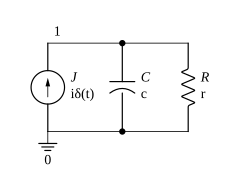

In [3]:
c1 = '''
j,0,1,i*δ(t)
c,1,0,c,0
r,1,0,r
'''
draw(c1)

In [4]:
r1 = tr(c1)
r1

Result(domain='tr')
  i_c = i*DiracDelta(t) - i*exp(-t/(c*r))/(c*r)
  i_j = i*DiracDelta(t)
  i_r = i*exp(-t/(c*r))/(c*r)
  v_1 = i*exp(-t/(c*r))/c

## 2. Bo2's Drill Exercise 5.13 (Impulse)

Example 5.7's op-amp circuit driven by a 1 V impulse, δ(t): find vc, ic and vo.

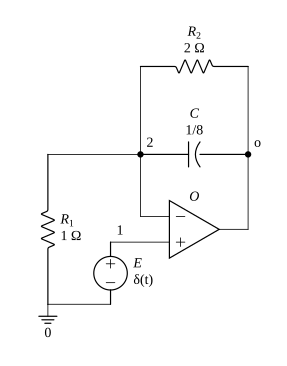

In [5]:
c2 = '''
e,1,0,δ(t)
o,1,2,o
c,2,o,1/8,0
r2,2,o,2
r1,2,0,1
'''
draw(c2)

In [6]:
r2 = tr(c2)
r2

Result(domain='tr')
  i_c = -DiracDelta(t) + 4*exp(-4*t)
  i_e = 0
  i_o = DiracDelta(t)
  i_r1 = DiracDelta(t)
  i_r2 = -4*exp(-4*t)
  v_1 = DiracDelta(t)
  v_2 = DiracDelta(t)
  v_o = DiracDelta(t) + 8*exp(-4*t)

## 3. Bo2's Figure 5.39 (Ramp)

A ramp source, written i*t: find iL and vL.

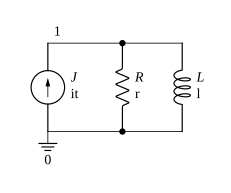

In [7]:
c3 = '''
j,0,1,i*t
r,1,0,r
l,1,0,l,0
'''
draw(c3)

In [8]:
r3 = tr(c3)
r3

Result(domain='tr')
  i_j = i*t
  i_l = -i*l/r + i*l*exp(-r*t/l)/r + i*t
  i_r = i*l/r - i*l*exp(-r*t/l)/r
  v_1 = i*l - i*l*exp(-r*t/l)

## 4. Bo2's Drill Exercise 5.14 (Ramp)

Example 5.7's circuit with a ramp input, t: find vc and ic.

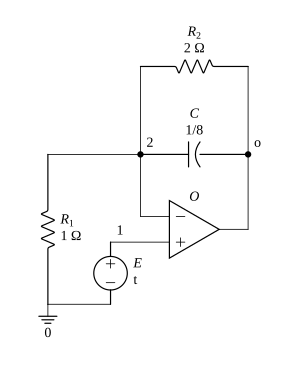

In [9]:
c4 = '''
e,1,0,t
o,1,2,o
c,2,o,1/8,0
r2,2,o,2
r1,2,0,1
'''
draw(c4)

In [10]:
r4 = tr(c4)
r4

Result(domain='tr')
  i_c = -1/4 + exp(-4*t)/4
  i_e = 0
  i_o = t
  i_r1 = t
  i_r2 = -t + 1/4 - exp(-4*t)/4
  v_1 = t
  v_2 = t
  v_o = 3*t - 1/2 + exp(-4*t)/2

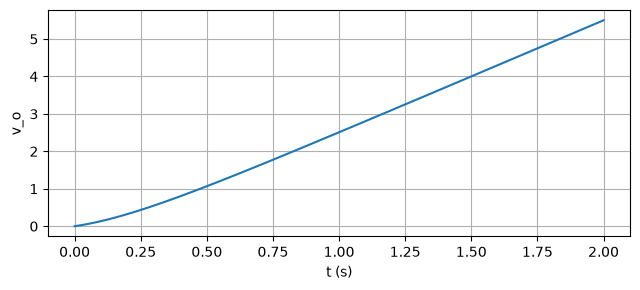

In [11]:
ts, ys = time_samples(c4, 'v_o', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 5. Bo2's Example 5.12 (Exponential)

An exponential source, 2e^(-4t): find iL and vL.

![The circuit of Bo2's Example 5.12 (Exponential)](https://learn.symbulator.com/assets/practice/bo2s-example-5-12-exponential-28.jpg)

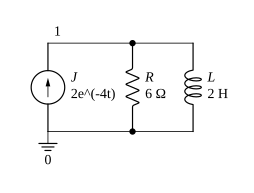

In [12]:
c5 = '''
j,0,1,2e^(-4t)
r,0,1,6
l,1,0,2,0
'''
draw(c5)

In [13]:
r5 = tr(c5)
r5

Result(domain='tr')
  i_j = 2*exp(-4*t)
  i_l = (6*exp(t) - 6)*exp(-4*t)
  i_r = 2*(3*exp(t) - 4)*exp(-4*t)
  v_1 = 12*(4 - 3*exp(t))*exp(-4*t)

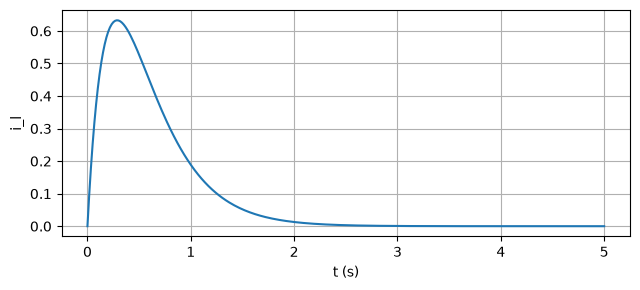

In [14]:
ts, ys = time_samples(c5, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 6. Bo2's p265 (Exponential, the repeated pole)

Find iL and vL again. The same circuit as the previous entry with the source's exponent changed from -4 to -3, which is the circuit's own pole -- hence the t in the answer.

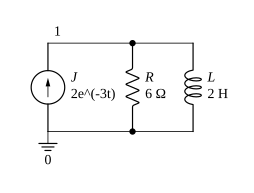

In [15]:
c6 = '''
j,0,1,2e^(-3t)
r,0,1,6
l,1,0,2,0
'''
draw(c6)

In [16]:
r6 = tr(c6)
r6

Result(domain='tr')
  i_j = 2*exp(-3*t)
  i_l = 6*t*exp(-3*t)
  i_r = 2*(3*t - 1)*exp(-3*t)
  v_1 = 12*(1 - 3*t)*exp(-3*t)

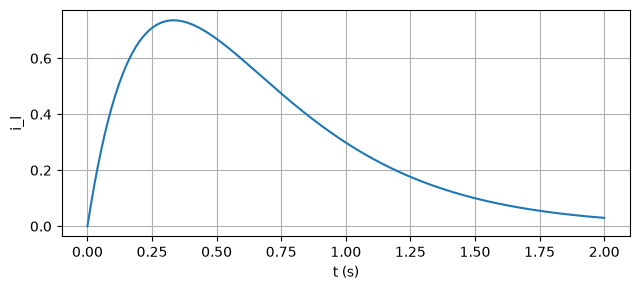

In [17]:
ts, ys = time_samples(c6, 'i_l', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 7. Bo2's Example 5.13 (Exponential)

An exponential source, 18e^(-t/2), on the dependent-source circuit of Figure 5.36: find the capacitor's voltage drop and the current in the 3 ohm resistor.

![The circuit of Bo2's Example 5.13 (Exponential)](https://learn.symbulator.com/assets/practice/bo2s-example-5-13-exponential-29.jpg)

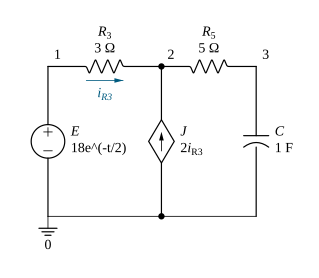

In [18]:
c7 = '''
e,1,0,18e^(-t/2)
r3,1,2,3
r5,2,3,5
c,3,0,1,0
j,0,2,2*ir3
'''
draw(c7)

In [19]:
r7 = tr(c7)
r7

Result(domain='tr')
  i_c = 9*exp(-t/2)/2 - 3*exp(-t/6)/2
  i_e = -3*exp(-t/2)/2 + exp(-t/6)/2
  i_j = 3*exp(-t/2) - exp(-t/6)
  i_r3 = 3*exp(-t/2)/2 - exp(-t/6)/2
  i_r5 = 9*exp(-t/2)/2 - 3*exp(-t/6)/2
  v_1 = 18*exp(-t/2)
  v_2 = 27*exp(-t/2)/2 + 3*exp(-t/6)/2
  v_3 = -9*exp(-t/2) + 9*exp(-t/6)

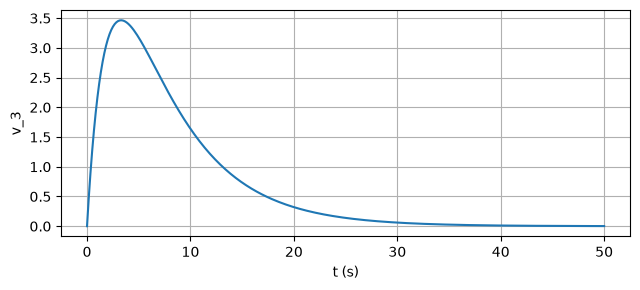

In [20]:
ts, ys = time_samples(c7, 'v_3', 50, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_3'); plt.grid(True); plt.tight_layout()

## 8. Bo2's Drill Exercise 5.16 (Exponential)

Example 5.7's circuit driven at its own pole, 2e^(-4t): find vc and ic — both answers carry a t.

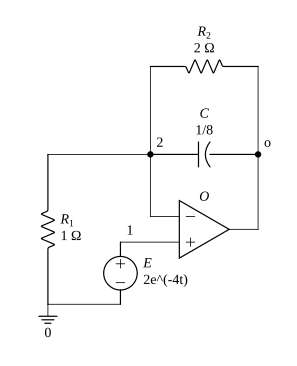

In [21]:
c8 = '''
e,1,0,2e^(-4t)
o,1,2,o
c,2,o,1/8,0
r2,2,o,2
r1,2,0,1
'''
draw(c8)

In [22]:
r8 = tr(c8)
r8

Result(domain='tr')
  i_c = 2*(4*t - 1)*exp(-4*t)
  i_e = 0
  i_o = 2*exp(-4*t)
  i_r1 = 2*exp(-4*t)
  i_r2 = -8*t*exp(-4*t)
  v_1 = 2*exp(-4*t)
  v_2 = 2*exp(-4*t)
  v_o = 2*(8*t + 1)*exp(-4*t)

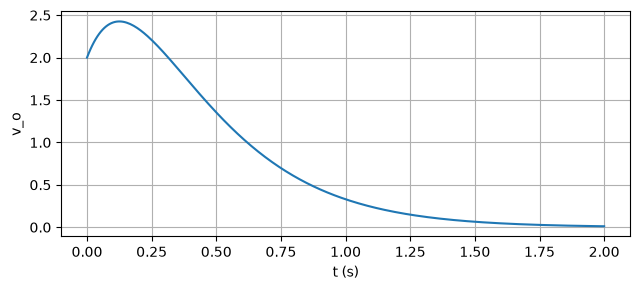

In [23]:
ts, ys = time_samples(c8, 'v_o', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('v_o'); plt.grid(True); plt.tight_layout()

## 9. Bo2's Example 6.1 (DC, second order)

The first second-order circuit: an inductor and a capacitor in the same network. Find i(t) and v(t) for all t; this DC interval gives vc = 2 V and il = 1 A.

![The circuit of Bo2's Example 6.1 (DC, second order)](https://learn.symbulator.com/assets/practice/bo2s-example-6-1-30.jpg)

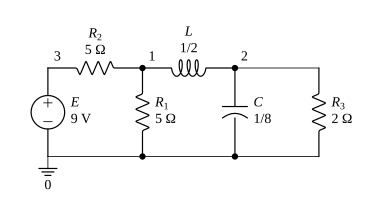

In [24]:
c9 = '''
e,3,0,9
r2,3,1,5
r1,1,0,5
l,1,2,1/2
c,2,0,1/8
r3,2,0,2
'''
draw(c9)

In [25]:
r9 = dc(c9)
r9

Result(domain='dc')
  i_c = 0
  i_e = -7/5
  i_l = 1
  i_r1 = 2/5
  i_r2 = 7/5
  i_r3 = 1
  p_c = 0
  p_e = -63/5
  p_l = 0
  p_r1 = 4/5
  p_r2 = 49/5
  p_r3 = 2
  r_e = 45/7
  v_1 = 2
  v_2 = 2
  v_3 = 9
  v_c = 2
  v_e = 9
  v_l = 0
  v_r1 = 2
  v_r2 = 7
  v_r3 = 2

## 10. Bo2's Example 6.1 (TR, second order)

Second interval in TR: two exponentials now. Find vc and il, built from e^(-2t) and e^(-8t).

![The circuit of Bo2's Example 6.1 (TR, second order)](https://learn.symbulator.com/assets/practice/bo2s-example-6-1-30.jpg)

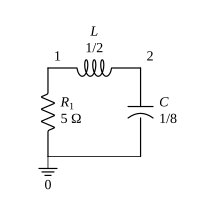

In [26]:
c10 = '''
r1,1,0,5
l,1,2,1/2,1
c,2,0,1/8,2
'''
draw(c10)

In [27]:
r10 = tr(c10)
r10

Result(domain='tr')
  i_c = (2 - exp(6*t))*exp(-8*t)
  i_l = (2 - exp(6*t))*exp(-8*t)
  i_r1 = (exp(6*t) - 2)*exp(-8*t)
  v_1 = 5*(exp(6*t) - 2)*exp(-8*t)
  v_2 = 2*(2*exp(6*t) - 1)*exp(-8*t)

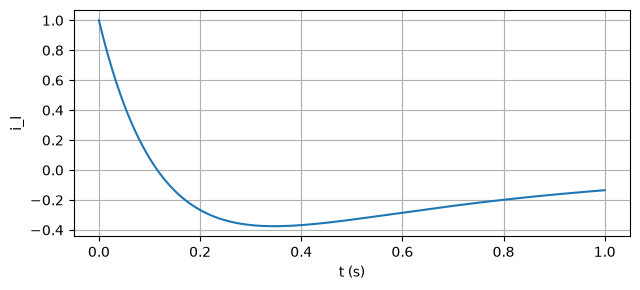

In [28]:
ts, ys = time_samples(c10, 'i_l', 1, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 11. Bo2's Drill Exercise 6.1 (DC)

First interval in DC: vc = 2 V and il = 0.

![The circuit of Bo2's Drill Exercise 6.1 (DC)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-1-32.jpg)

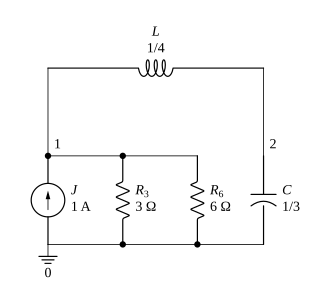

In [29]:
c11 = '''
j,0,1,1
r3,1,0,3
r6,1,0,6
l,1,2,1/4
c,2,0,1/3
'''
draw(c11)

In [30]:
r11 = dc(c11)
r11

Result(domain='dc')
  i_c = 0
  i_j = 1
  i_l = 0
  i_r3 = 2/3
  i_r6 = 1/3
  p_c = 0
  p_j = -2
  p_l = 0
  p_r3 = 4/3
  p_r6 = 2/3
  r_j = 2
  v_1 = 2
  v_2 = 2
  v_c = 2
  v_j = -2
  v_l = 0
  v_r3 = 2
  v_r6 = 2

## 12. Bo2's Drill Exercise 6.1 (TR)

Second interval in TR: find vc and il, each a pair of exponentials.

![The circuit of Bo2's Drill Exercise 6.1 (TR)](https://learn.symbulator.com/assets/practice/bo2s-drill-exercise-6-1-32.jpg)

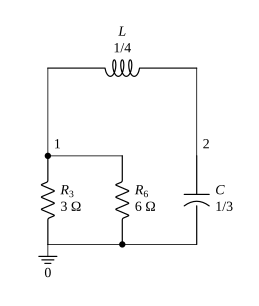

In [31]:
c12 = '''
r3,1,0,3
r6,1,0,6
l,1,2,1/4,0
c,2,0,1/3,2
'''
draw(c12)

In [32]:
r12 = tr(c12)
r12

Result(domain='tr')
  i_c = 2*(1 - exp(4*t))*exp(-6*t)
  i_l = 2*(1 - exp(4*t))*exp(-6*t)
  i_r3 = (4*exp(4*t) - 4)*exp(-6*t)/3
  i_r6 = (2*exp(4*t) - 2)*exp(-6*t)/3
  v_1 = (4*exp(4*t) - 4)*exp(-6*t)
  v_2 = (3*exp(4*t) - 1)*exp(-6*t)

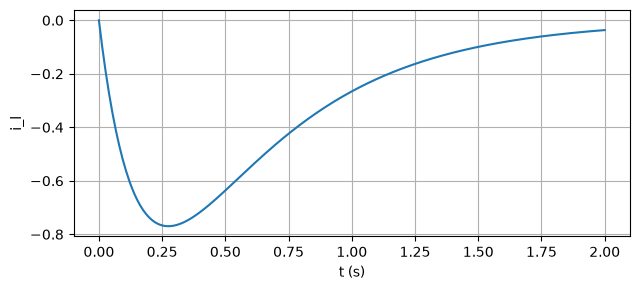

In [33]:
ts, ys = time_samples(c12, 'i_l', 2, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 13. Bo2's Example 6.2 (DC, the left half)

For t < 0 the switches split this circuit in two. The left half's DC solve gives the capacitor's initial condition, -7/50 V — solved in fractions on purpose.

![The circuit of Bo2's Example 6.2 (DC, the left half)](https://learn.symbulator.com/assets/practice/bo2s-example-6-2-33.jpg)

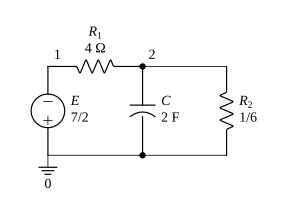

In [34]:
c13 = '''
e,0,1,7/2
r1,1,2,4
c,2,0,2
r2,2,0,1/6
'''
draw(c13)

In [35]:
r13 = dc(c13)
r13

Result(domain='dc')
  i_c = 0
  i_e = -21/25
  i_r1 = -21/25
  i_r2 = -21/25
  p_c = 0
  p_e = -147/50
  p_r1 = 1764/625
  p_r2 = 147/1250
  r_e = 25/6
  v_1 = -7/2
  v_2 = -7/50
  v_c = -7/50
  v_e = 7/2
  v_r1 = -84/25
  v_r2 = -7/50

## 14. Bo2's Example 6.2 (DC, the right half)

The right half's DC solve gives the inductor's initial condition, 1 A.

![The circuit of Bo2's Example 6.2 (DC, the right half)](https://learn.symbulator.com/assets/practice/bo2s-example-6-2-33.jpg)

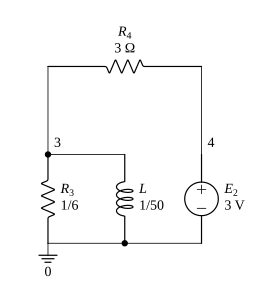

In [36]:
c14 = '''
r3,3,0,1/6
l,3,0,1/50
r4,3,4,3
e2,4,0,3
'''
draw(c14)

In [37]:
r14 = dc(c14)
r14

Result(domain='dc')
  i_e2 = -1
  i_l = 1
  i_r3 = 0
  i_r4 = -1
  p_e2 = -3
  p_l = 0
  p_r3 = 0
  p_r4 = 3
  r_e2 = 3
  v_3 = 0
  v_4 = 3
  v_e2 = 3
  v_l = 0
  v_r3 = 0
  v_r4 = -3

## 15. Bo2's Example 6.2 (TR, both halves joined)

The TR interval, both halves joined: find vc and il — underdamped now, decaying sinusoids in cos(4t) and sin(4t). The switch on the right is simulated as a short between the two halves, which saves renaming every node.

![The circuit of Bo2's Example 6.2 (TR, both halves joined)](https://learn.symbulator.com/assets/practice/bo2s-example-6-2-33.jpg)

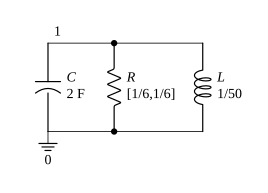

In [38]:
c15 = '''
c,1,0,2,-7/50
r,1,0,[1/6,1/6]
l,1,0,1/50,1
'''
draw(c15)

In [39]:
r15 = tr(c15)
r15

Result(domain='tr')
  i_c = (31*sin(4*t) + 17*cos(4*t))*exp(-3*t)/25
  i_l = (-sin(4*t) + cos(4*t))*exp(-3*t)
  i_r = 6*(-sin(4*t) - 7*cos(4*t))*exp(-3*t)/25
  v_1 = (-sin(4*t) - 7*cos(4*t))*exp(-3*t)/50

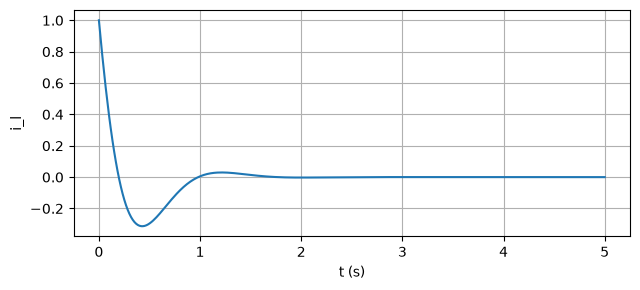

In [40]:
ts, ys = time_samples(c15, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 16. Bo2's Example 6.3 (DC)

First interval in DC: vc = 2 V and il = 1 A.

![The circuit of Bo2's Example 6.3 (DC)](https://learn.symbulator.com/assets/practice/bo2s-example-6-3-34.jpg)

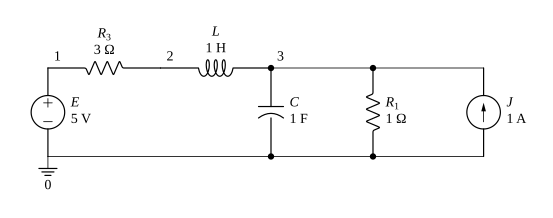

In [41]:
c16 = '''
e,1,0,5
r3,1,2,3
l,2,3,1
c,3,0,1
r1,3,0,1
j,0,3,1
'''
draw(c16)

In [42]:
r16 = dc(c16)
r16

Result(domain='dc')
  i_c = 0
  i_e = -1
  i_j = 1
  i_l = 1
  i_r1 = 2
  i_r3 = 1
  p_c = 0
  p_e = -5
  p_j = -2
  p_l = 0
  p_r1 = 4
  p_r3 = 3
  r_e = 5
  r_j = 2
  v_1 = 5
  v_2 = 2
  v_3 = 2
  v_c = 2
  v_e = 5
  v_j = -2
  v_l = 0
  v_r1 = 2
  v_r3 = 3

## 17. Bo2's Example 6.3 (TR)

Second interval in TR: a repeated pole this time. Find vc and il, each carrying a t·e^(-2t) term.

![The circuit of Bo2's Example 6.3 (TR)](https://learn.symbulator.com/assets/practice/bo2s-example-6-3-34.jpg)

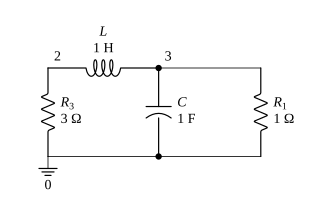

In [43]:
c17 = '''
r3,0,2,3
l,2,3,1,1
c,3,0,1,2
r1,3,0,1
'''
draw(c17)

In [44]:
r17 = tr(c17)
r17

Result(domain='tr')
  i_c = (-6*t - 1)*exp(-2*t)
  i_l = (1 - 3*t)*exp(-2*t)
  i_r1 = (3*t + 2)*exp(-2*t)
  i_r3 = (1 - 3*t)*exp(-2*t)
  v_2 = 3*(3*t - 1)*exp(-2*t)
  v_3 = (3*t + 2)*exp(-2*t)

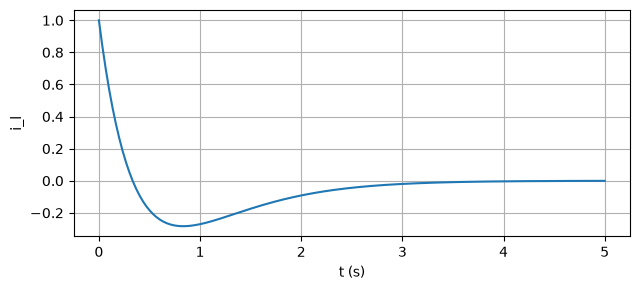

In [45]:
ts, ys = time_samples(c17, 'i_l', 5, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()